# **IML Project**

## **Problem Statement:**

Build an RBF-kernel SVM to predict credit card default using the default of credit card client dataset. Split the dataset into train and test sets and use the train set to build the SVM. Implement SHAP and use it to explain the predictions on the test set.

## **Team Members:**

1) 25AI60R05 - Satya Sree Patheti

2) 25AI60R06 - R Sreelekshmi

3) 25AI60R13 - Padma Pedapolu

4) 25AI60R24 - Anarva Kamdar (Team Leader)

5) 25AI60R29 - Atharva Pote

## **About the Dataset**

**Link of Dataset:**

https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

**Dataset Info:**

*   Dataset size = 30,000 rows
*   Number of Features = 23
*   Target Variable = default payment next month (Yes=1, No=0)
*   Used for classification purposes, in business-related domain


**Features Info:**

**X1:**

Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit

**X2:** Gender
* 1 = male
* 2 = female

**X3:** Education
* 1 = graduate school
* 2 = university
* 3 = high school
* 4 = others

**X4:** Marital status
* 1 = married
* 2 = single
* 3 = others

**X5:** Age (year)

**X6 - X11: History of past payment:**


* X6 = the repayment status in September 2005
* X7 = the repayment status in August 2005
* X8 = the repayment status in July 2005
* X9 = the repayment status in June 2005
* X10 = the repayment status in May 2005
* X11 = the repayment status in April 2005

**Measurement Scale:**

* -1 = pay duly
* 1 = payment delay for 1 month
* 2 = payment delay for 2 months
* 3 = payment delay for 3 months
* 4 = payment delay for 4 months
* 5 = payment delay for 5 months
* 6 = payment delay for 6 months
* 7 = payment delay for 7 months
* 8 = payment delay for 8 months
* 9 = payment delay for 9 months and above


**X12-X17: Amount of bill statement (NT dollar):**

* X12 = amount of bill statement in September 2005
* X13 = amount of bill statement in August 2005
* X14 = amount of bill statement in July 2005
* X15 = amount of bill statement in June 2005
* X16 = amount of bill statement in May 2005
* X17 = amount of bill statement in April 2005.

**X18-X23: Amount of previous payment (NT dollar):**

* X18 = amount paid in September 2005
* X19 = amount paid in August 2005
* X20 = amount paid in July 2005
* X21 = amount paid in June 2005
* X22 = amount paid in May 2005
* X23 = amount paid in April 2005

## **Imports**

In [1]:
!pip install ucimlrepo

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from ucimlrepo import fetch_ucirepo
import math
import itertools
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import normalized_mutual_info_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


## **Loading Dataset**

In [3]:
# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)

# data (as pandas dataframes)
X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

# metadata
# print(default_of_credit_card_clients.metadata)

# variable information
# print(default_of_credit_card_clients.variables)

In [4]:
all_features=list(X.columns)
print(all_features)

['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']


In [5]:
for col in all_features:
    print(col, ":", X[col].dtype)

X1 : int64
X2 : int64
X3 : int64
X4 : int64
X5 : int64
X6 : int64
X7 : int64
X8 : int64
X9 : int64
X10 : int64
X11 : int64
X12 : int64
X13 : int64
X14 : int64
X15 : int64
X16 : int64
X17 : int64
X18 : int64
X19 : int64
X20 : int64
X21 : int64
X22 : int64
X23 : int64


## **Preprocessing**

### Null Values

In [6]:
null_values=[]

for f in all_features:
  null_values.append(X[f].isnull().sum())

print(null_values)
print(y.isnull().sum())

[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
Y    0
dtype: int64


***No Null Values detected***

### Duplicates

In [7]:
print("Original Length of rows: ",len(X))

Original Length of rows:  30000


In [8]:
duplicates=X.duplicated()

ind=X[duplicates].index

X=X.drop(index=ind)
y=y.drop(index=ind)

In [9]:
print("New length of rows: ",len(X),len(y))

New length of rows:  29944 29944


***Removed 56 duplicates***

### Admissible/Valid entries

In [10]:
print(y['Y'].unique())

[1 0]


In [11]:
categorical_features=['X2','X3','X4','X6','X7','X8','X9','X10','X11']
numeric_features=['X1','X5','X12','X13','X14','X15','X16','X17','X18','X19','X20','X21','X22','X23']

r_c={}
for f in categorical_features:
  u=list(X[f].unique())
  r_c[f]=u

print(r_c)

r_n={}
for f in numeric_features:
  u=[X[f].min(),X[f].max()]
  r_n[f]=u

print(r_n)

{'X2': [np.int64(2), np.int64(1)], 'X3': [np.int64(2), np.int64(1), np.int64(3), np.int64(5), np.int64(4), np.int64(6), np.int64(0)], 'X4': [np.int64(1), np.int64(2), np.int64(3), np.int64(0)], 'X6': [np.int64(2), np.int64(-1), np.int64(0), np.int64(-2), np.int64(1), np.int64(3), np.int64(4), np.int64(8), np.int64(7), np.int64(5), np.int64(6)], 'X7': [np.int64(2), np.int64(0), np.int64(-1), np.int64(-2), np.int64(3), np.int64(5), np.int64(7), np.int64(4), np.int64(1), np.int64(6), np.int64(8)], 'X8': [np.int64(-1), np.int64(0), np.int64(2), np.int64(-2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(1), np.int64(5), np.int64(8)], 'X9': [np.int64(-1), np.int64(0), np.int64(-2), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(6), np.int64(1), np.int64(8)], 'X10': [np.int64(-2), np.int64(0), np.int64(-1), np.int64(2), np.int64(3), np.int64(5), np.int64(4), np.int64(7), np.int64(8), np.int64(6)], 'X11': [np.int64(-2), np.int64(2), np.int64(0), np.in

X3 should have values only [1,2,3,4] but has values [0,1,2,3,4,5,6].

X4 has values [0,1,2,3] but should have [1,2,3], probably 0 here means information has not been collected.

For X6-X11, it seems that there is discrepancy: The metadata says the range of values is from [-1 to 9] but the values are from [-2 to 8].

As for the numeric features it doesn't seem to have any discrepancies.

**For X3:**

* 1 = graduate school
* 2 = university
* 3 = high school
* 4 = others

In [12]:
print(X['X3'].value_counts())

X3
2    14011
1    10552
3     4913
5      280
4      123
6       51
0       14
Name: count, dtype: int64


So the invalid values nearly make up 1.56% of the total data, but since we are already having 4=others, we will put all values in it.

In [13]:
X.loc[X['X3'].isin([0, 5, 6]),'X3']=4
print(X['X3'].value_counts())

X3
2    14011
1    10552
3     4913
4      468
Name: count, dtype: int64


**For X4:**

* 1 = married
* 2 = single
* 3 = others

In [14]:
print(X['X4'].value_counts())

X4
2    15935
1    13632
3      323
0       54
Name: count, dtype: int64


Since 54 rows have value 0, we can safely include it in others

In [15]:
X.loc[X['X4'].isin([0]),'X4']=3
print(X['X4'].value_counts())

X4
2    15935
1    13632
3      377
Name: count, dtype: int64


**For X6-X11:**

Given Range = [-1 to 9] but has range [-2 to 8], considering that "-2" is a new category, which may represent no sonsumption or billing for that month.

In [16]:
for i in range(6,12):
  f='X'+str(i)
  print(X[f].value_counts())


X6
 0    14737
-1     5682
 1     3650
-2     2747
 2     2665
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64
X7
 0    15730
-1     6046
 2     3925
-2     3732
 3      326
 4       99
 1       28
 5       25
 7       20
 6       12
 8        1
Name: count, dtype: int64
X8
 0    15764
-1     5934
-2     4035
 2     3819
 3      240
 4       74
 7       27
 6       23
 5       21
 1        4
 8        3
Name: count, dtype: int64
X9
 0    16455
-1     5683
-2     4298
 2     3159
 3      180
 4       67
 7       58
 5       35
 6        5
 1        2
 8        2
Name: count, dtype: int64
X10
 0    16947
-1     5535
-2     4496
 2     2626
 3      178
 4       82
 7       58
 5       17
 6        4
 8        1
Name: count, dtype: int64
X11
 0    16286
-1     5736
-2     4845
 2     2766
 3      184
 4       47
 7       46
 6       19
 5       13
 8        2
Name: count, dtype: int64


### After preprocessing

In [17]:
print(X.head())
print(y.head())

       X1  X2  X3  X4  X5  X6  X7  X8  X9  X10  ...    X14    X15    X16  \
0   20000   2   2   1  24   2   2  -1  -1   -2  ...    689      0      0   
1  120000   2   2   2  26  -1   2   0   0    0  ...   2682   3272   3455   
2   90000   2   2   2  34   0   0   0   0    0  ...  13559  14331  14948   
3   50000   2   2   1  37   0   0   0   0    0  ...  49291  28314  28959   
4   50000   1   2   1  57  -1   0  -1   0    0  ...  35835  20940  19146   

     X17   X18    X19    X20   X21   X22   X23  
0      0     0    689      0     0     0     0  
1   3261     0   1000   1000  1000     0  2000  
2  15549  1518   1500   1000  1000  1000  5000  
3  29547  2000   2019   1200  1100  1069  1000  
4  19131  2000  36681  10000  9000   689   679  

[5 rows x 23 columns]
   Y
0  1
1  1
2  0
3  0
4  0


## **Visualization**

**Class Distribution**

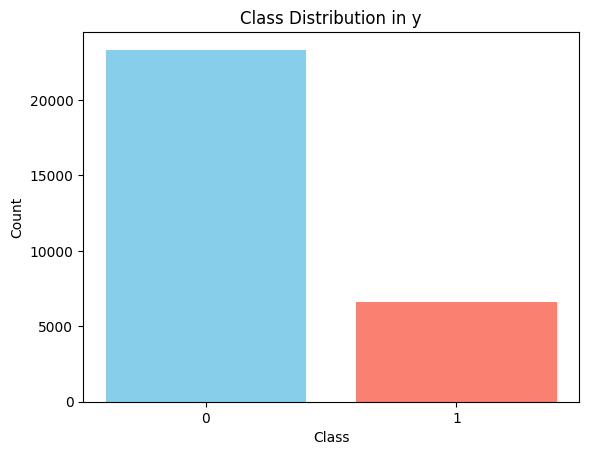

Y
0    23322
1     6622
Name: count, dtype: int64


In [18]:
counts=y['Y'].value_counts().sort_index()

# Bar plot
plt.bar(counts.index.astype(str),counts.values,color=["skyblue","salmon"])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution in y")
plt.show()

print(counts)

This is an imbalanced dataset.

Class 1 means that "yes" or the client does **default** which means that they fail to make the required payment next month, so majority of the people are from class 0 meaning they are able to make the required payment next month.

**Feature Correlation**

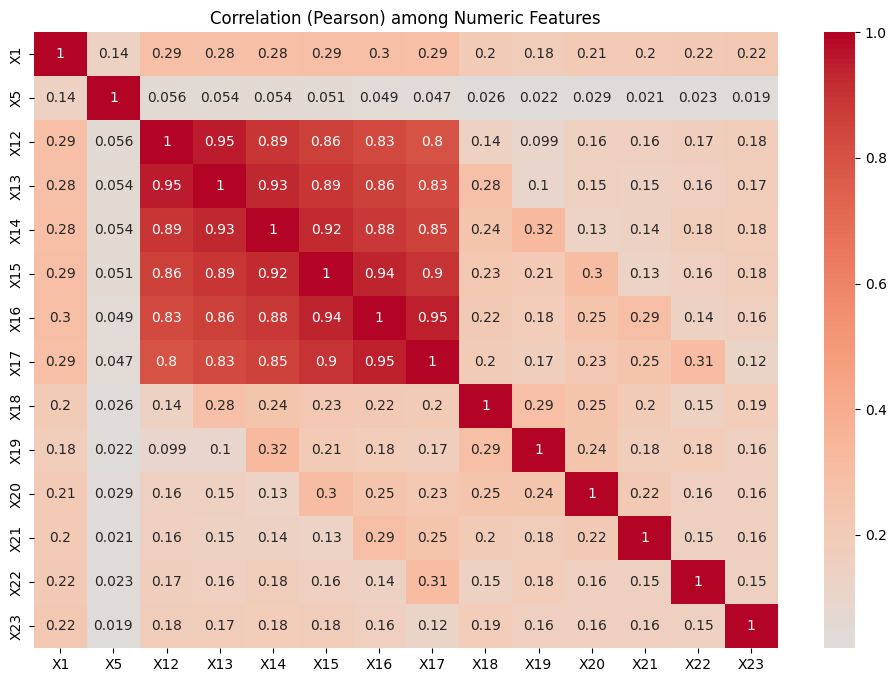

In [19]:
corr_num=X[numeric_features].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_num,annot=True,cmap="coolwarm",center=0)
plt.title("Correlation (Pearson) among Numeric Features")
plt.show()

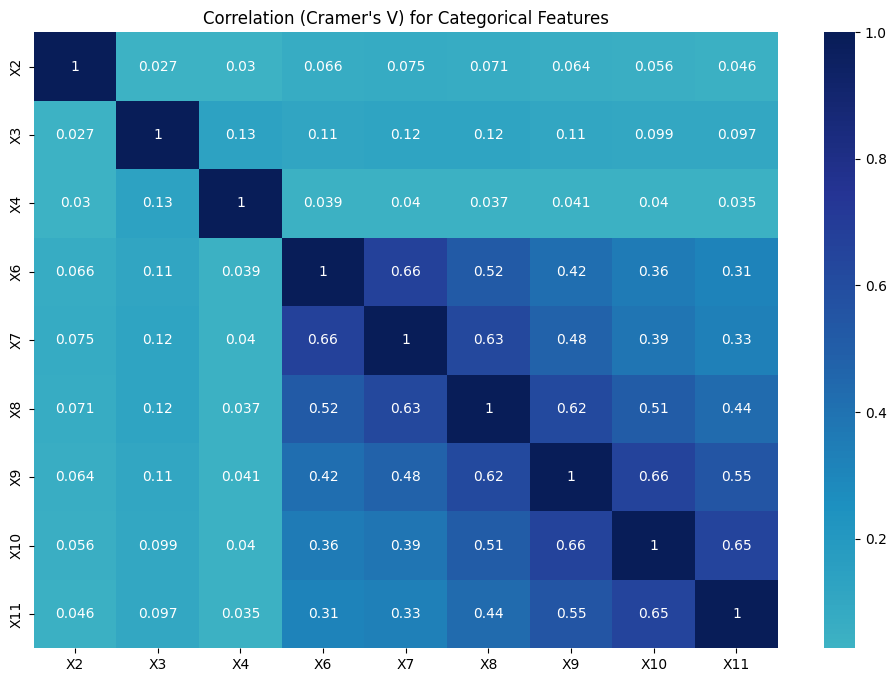

In [20]:
def cramers_v(x, y):
  confusion_matrix=pd.crosstab(x,y)
  chi2=chi2_contingency(confusion_matrix)[0]
  n=confusion_matrix.sum().sum()
  phi2=(chi2/n)
  r,k=confusion_matrix.shape
  phi2corr=max(0,phi2-((k-1)*(r-1))/(n-1))
  rcorr=r-((r-1)**2)/(n-1)
  kcorr=k-((k-1)**2)/(n-1)
  return np.sqrt(phi2corr/min((kcorr-1),(rcorr-1)))

cat_corr=pd.DataFrame(np.zeros((len(categorical_features),len(categorical_features))),index=categorical_features,columns=categorical_features)

for i,col1 in enumerate(categorical_features):
  for j,col2 in enumerate(categorical_features):
    if(i<=j):
      val=cramers_v(X[col1],X[col2])
      cat_corr.loc[col1,col2]=val
      cat_corr.loc[col2,col1]=val

plt.figure(figsize=(12,8))
sns.heatmap(cat_corr,annot=True,cmap="YlGnBu",center=0)
plt.title("Correlation (Cramer's V) for Categorical Features")
plt.show()


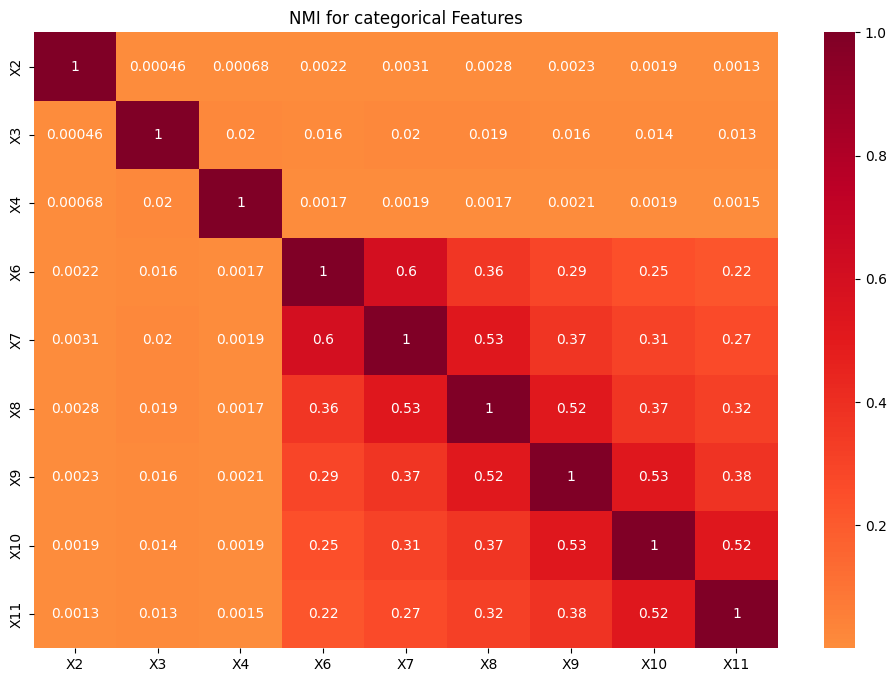

In [21]:
n=len(categorical_features)
nmi_matrix=pd.DataFrame(np.zeros((n,n)),index=categorical_features,columns=categorical_features)

for i,col1 in enumerate(categorical_features):
  for j,col2 in enumerate(categorical_features):
    if(i<=j):
      val=normalized_mutual_info_score(X[col1],X[col2])
      nmi_matrix.loc[col1,col2]=val
      nmi_matrix.loc[col2,col1]=val

plt.figure(figsize=(12,8))
sns.heatmap(nmi_matrix,annot=True,cmap="YlOrRd",center=0)
plt.title("NMI for categorical Features")
plt.show()


## **Splitting and Feature Scaling**

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [23]:
X_train_encoded=pd.get_dummies(X_train,columns=categorical_features,prefix=categorical_features)
X_test_encoded=pd.get_dummies(X_test,columns=categorical_features,prefix=categorical_features)

X_train_encoded,X_test_encoded=X_train_encoded.align(X_test_encoded,join='left',axis=1,fill_value=0)

In [24]:
scaler=MinMaxScaler()
X_train_encoded[numeric_features]=scaler.fit_transform(X_train_encoded[numeric_features])
X_test_encoded[numeric_features]=scaler.transform(X_test_encoded[numeric_features])

In [25]:
print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)

X_train_encoded shape: (20960, 84)
X_test_encoded shape: (8984, 84)


In [26]:
bool_cols1=X_train_encoded.select_dtypes(include='bool').columns
X_train_encoded[bool_cols1] = X_train_encoded[bool_cols1].astype(int)

bool_cols2=X_test_encoded.select_dtypes(include='bool').columns
X_test_encoded[bool_cols2] = X_test_encoded[bool_cols2].astype(int)


In [27]:
print(X_train_encoded,X_test_encoded)

             X1        X5       X12       X13       X14       X15       X16  \
20465  0.181818  0.068966  0.149327  0.071222  0.089112  0.074436  0.068605   
2847   0.171717  0.068966  0.272028  0.199836  0.165418  0.221276  0.213099   
18809  0.040404  0.155172  0.174132  0.088661  0.099751  0.095223  0.089464   
9383   0.353535  0.120690  0.146519  0.066220  0.086345  0.068113  0.062083   
25972  0.191919  0.172414  0.146519  0.066220  0.086345  0.068113  0.062083   
...         ...       ...       ...       ...       ...       ...       ...   
19546  0.020202  0.258621  0.170000  0.091969  0.101330  0.097225  0.090441   
24491  0.464646  0.189655  0.163703  0.076665  0.094674  0.096667  0.093472   
7808   0.040404  0.137931  0.188872  0.112022  0.096918  0.088252  0.081344   
10266  0.050505  0.155172  0.146519  0.066220  0.086345  0.068113  0.062083   
21695  0.262626  0.068966  0.166499  0.088598  0.099858  0.094888  0.087812   

            X17       X18       X19  ...  X10_7  X1

## **SVM**

In [28]:
svm = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm.fit(X_train_encoded, y_train)

# Predict
y_pred = svm.predict(X_test_encoded)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[6699  298]
 [1314  673]]
              precision    recall  f1-score   support

           0       0.84      0.96      0.89      6997
           1       0.69      0.34      0.46      1987

    accuracy                           0.82      8984
   macro avg       0.76      0.65      0.67      8984
weighted avg       0.80      0.82      0.80      8984



## **SHAP from Scratch**

Since it is not feasable to get all 84 features, due to limitations in memory and computation for Colab, we restrict our implementation for 15 features as 2^84 combinations is too much to handle.


We find the most influencial features using random forest and proceed with only understanding the SHAP for those features.

In [29]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_encoded, y_train)
importance = rf.feature_importances_
top_features = list(X_train_encoded.columns[np.argsort(importance)[-15:][::-1]])
print(top_features)

['X5', 'X1', 'X12', 'X6_2', 'X13', 'X14', 'X15', 'X17', 'X16', 'X18', 'X19', 'X20', 'X23', 'X21', 'X22']


### **Pre-requisites**

In [30]:
data=X_test_encoded.copy()
print(data.shape)
print(data.head())

(8984, 84)
             X1        X5       X12       X13       X14       X15       X16  \
4786   0.090909  0.603448  0.232839  0.163841  0.140683  0.141645  0.131060   
8775   0.494949  0.137931  0.164784  0.090882  0.099368  0.089852  0.096611   
6739   0.000000  0.189655  0.154893  0.075082  0.091875  0.078626  0.071956   
22974  0.202020  0.189655  0.146833  0.067146  0.086570  0.068113  0.062083   
8541   0.484848  0.500000  0.162344  0.072708  0.088901  0.071664  0.063576   

            X17       X18       X19  ...  X10_7  X11_-2  X11_-1  X11_0  X11_2  \
4786   0.237111  0.010646  0.000000  ...      0       0       0      1      0   
8775   0.227184  0.029891  0.014316  ...      0       0       1      0      0   
6739   0.187150  0.001334  0.000712  ...      0       0       0      1      0   
22974  0.178567  0.001121  0.000245  ...      0       1       0      0      0   
8541   0.179935  0.007826  0.002765  ...      0       0       1      0      0   

       X11_3  X11_4  X11_5 

**Creating a Mapping for the new and old feature names**

Idea is to create consistent feature names so later we can see clearly the combinations of those features when written. For example, renaming them as 'a1','a2',... etc are features then any combinations will be of form 'a1a5a2' which can be easily inferred which features form this coalition.

In [31]:
new_names = {old: f'a{i+1}' for i, old in enumerate(data.columns)}
data = data.rename(columns=new_names)
top_features = [new_names[feat] for feat in top_features]
inverse_names = {v: k for k, v in new_names.items()}

print(new_names)
print(inverse_names)
print(top_features)
print(data.head())

{'X1': 'a1', 'X5': 'a2', 'X12': 'a3', 'X13': 'a4', 'X14': 'a5', 'X15': 'a6', 'X16': 'a7', 'X17': 'a8', 'X18': 'a9', 'X19': 'a10', 'X20': 'a11', 'X21': 'a12', 'X22': 'a13', 'X23': 'a14', 'X2_1': 'a15', 'X2_2': 'a16', 'X3_1': 'a17', 'X3_2': 'a18', 'X3_3': 'a19', 'X3_4': 'a20', 'X4_1': 'a21', 'X4_2': 'a22', 'X4_3': 'a23', 'X6_-2': 'a24', 'X6_-1': 'a25', 'X6_0': 'a26', 'X6_1': 'a27', 'X6_2': 'a28', 'X6_3': 'a29', 'X6_4': 'a30', 'X6_5': 'a31', 'X6_6': 'a32', 'X6_7': 'a33', 'X6_8': 'a34', 'X7_-2': 'a35', 'X7_-1': 'a36', 'X7_0': 'a37', 'X7_1': 'a38', 'X7_2': 'a39', 'X7_3': 'a40', 'X7_4': 'a41', 'X7_5': 'a42', 'X7_6': 'a43', 'X7_7': 'a44', 'X7_8': 'a45', 'X8_-2': 'a46', 'X8_-1': 'a47', 'X8_0': 'a48', 'X8_1': 'a49', 'X8_2': 'a50', 'X8_3': 'a51', 'X8_4': 'a52', 'X8_5': 'a53', 'X8_6': 'a54', 'X8_7': 'a55', 'X8_8': 'a56', 'X9_-2': 'a57', 'X9_-1': 'a58', 'X9_0': 'a59', 'X9_1': 'a60', 'X9_2': 'a61', 'X9_3': 'a62', 'X9_4': 'a63', 'X9_5': 'a64', 'X9_6': 'a65', 'X9_7': 'a66', 'X10_-2': 'a67', 'X10_-1':

**Blackbox Function for Predictions**

In [32]:
def blackbox(model, input_vector):
  if isinstance(input_vector, pd.Series):
    x_input = input_vector.to_frame().T
  elif isinstance(input_vector, pd.DataFrame):
    x_input = input_vector
  else:
    x_input = pd.DataFrame([input_vector], columns=model.feature_names_in_)

  x_input = x_input.rename(columns=inverse_names)
  val=model.decision_function(x_input)

  return 1/(1+np.exp(-val))


**Helper Function**

This function splits the combinations into its constituent features and helps us in accessing the feature properly based on its numbering. For example the combination 'a1a3a4' gives ['a1','a3','a4'] and [1,3,4]

In [33]:
def split_by_a(combo_str):
  if combo_str == '':
    return [],[]
  parts = combo_str.split('a')
  ind = list((parts))
  ind2=[]
  for i in range(0,len(ind)):
    if(ind[i]==''):
      continue
    ind2.append(int(ind[i]))
  # after splitting, add 'a' back in front of each numeric part
  features = ['a' + p for p in parts if p]
  return features,ind2


**Average which will form base**

In [34]:
avgs=[]
for f in X_train_encoded:
  avgs.append(X_train_encoded[f].mean())

print(avgs)
print(len(avgs))

[np.float64(0.1592302798982188), np.float64(0.2496314819689392), np.float64(0.19215258549130823), np.float64(0.11327703924747087), np.float64(0.11234257073959567), np.float64(0.11380874415344207), np.float64(0.10321411978101815), np.float64(0.2120132889690658), np.float64(0.006553194382429787), np.float64(0.003591765947005422), np.float64(0.00594913170324321), np.float64(0.007807721171221005), np.float64(0.012653132744385578), np.float64(0.009808191993270132), np.float64(0.3987118320610687), np.float64(0.6012881679389313), np.float64(0.35376908396946566), np.float64(0.46784351145038167), np.float64(0.1623091603053435), np.float64(0.01607824427480916), np.float64(0.4541984732824427), np.float64(0.5342080152671755), np.float64(0.011593511450381679), np.float64(0.09188931297709924), np.float64(0.18893129770992367), np.float64(0.4924618320610687), np.float64(0.12237595419847329), np.float64(0.08907442748091603), np.float64(0.010543893129770993), np.float64(0.002719465648854962), np.float64

**All combinations/Coalitions**

In [35]:
chunk_size=1024
all_combinations=[]
current_chunk=[]

for i in range(len(top_features)+1):
    for combo in itertools.combinations(top_features,i):
      current_chunk.append(''.join(combo))
      if(len(current_chunk)==chunk_size):
        all_combinations.append(current_chunk)
        current_chunk=[]

# Add leftover as another chunk
if(current_chunk):
  all_combinations.append(current_chunk)

print("Number of chunks: {}".format(len(all_combinations)))

Number of chunks: 32


**Weights**

Here we compute the weights according to the Shapley value formula so later we can do the weighted sum of marginal contributions to get SHAP values. The formula is:

w=(s!)*(m-s-1)!/(m!)

where:

s = size of subset

m = number of features

In [36]:
weights=[]
m=len(top_features)
for s in range(0,len(top_features)):
  w=((math.factorial(s))*(math.factorial(m-s-1)))/(math.factorial(m))
  weights.append(w)

print(weights)

[0.06666666666666667, 0.004761904761904762, 0.0007326007326007326, 0.00018315018315018315, 6.66000666000666e-05, 3.33000333000333e-05, 2.22000222000222e-05, 1.9425019425019425e-05, 2.22000222000222e-05, 3.33000333000333e-05, 6.66000666000666e-05, 0.00018315018315018315, 0.0007326007326007326, 0.004761904761904762, 0.06666666666666667]


## **Explaining instance 1**

In [37]:
instance=data.iloc[0]

**Background Calculations**

This script, for every combination, it changes the base vector by replacing those feature values that appear in the combination by the instance we are interested in explaining and passes them to the blackbox function.

For example, if base vector=[0.5,0.5,0.5] and the combination is a1a3, and the instance of interest is [0,3,4] then it changes it as [0,0.5,4] and passes it to blackbox() for prediction.

In [38]:
backgrounds=[]

#for specified combo, change features and pass to blackbox
for chunk in all_combinations:
  chunk_results=[]
  for combo in chunk:
    fe,inw=split_by_a(combo)
    input_vector=list(avgs)
    for j in inw:
      input_vector[j-1]=instance[j-1]
    result=blackbox(svm,input_vector)
    chunk_results.append((fe,result))

  backgrounds.append(chunk_results)

print("Number of chunks in background1: {}".format(len(backgrounds)))
print("Number of elements in first chunk: {}".format(len(backgrounds[0])))


Number of chunks in background1: 32
Number of elements in first chunk: 1024


**Marginal Contributions**

In [39]:
#stores multiple M which are 2D matrices of each chunk
M_all = []

for chunk_idx,chunk in enumerate(all_combinations):
  # create M for this chunk
  M=np.full((len(chunk),len(top_features)+1),np.nan)

  # fill col0 - initialize
  for i in range(len(chunk)):
    M[i][0]=backgrounds[chunk_idx][i][1][0]

  # fill row0 - initialize
  for i in range(1,len(top_features)+1):
    if(i<len(chunk)):
      M[0][i]=backgrounds[chunk_idx][i][1][0]

  # fill remaining M entries
  for i in range(1, len(chunk)):
    comb_indices = split_by_a(chunk[i])[1]
    for j in range(1, len(top_features)+1):
      if j in comb_indices:
          continue

      # construct sorted_split for comparison
      sl1=split_by_a(chunk[i])[0].copy()
      sl1.append('a'+str(j))
      sorted_split=sorted(sl1, key=lambda x: int(x[1:]))

      # search in backgrounds of this chunk
      val=np.nan
      for k in range(len(chunk)):
        if(backgrounds[chunk_idx][k][0]==sorted_split):
          val=backgrounds[chunk_idx][k][1][0]
          break

      M[i][j]=val

  # subtract column 0 from other columns
  for i in range(1,len(top_features)+1):
    for j in range(len(chunk)):
      if np.isnan(M[j][i]):
        continue
      M[j][i]=M[j][i]-M[j][0]

  # append this chunk's M to the 3D list
  M_all.append(M)

# M_all is now 3D: len(M_all) = number of chunks, each M_all[i] = M for that chunk
print("Number of chunks (M matrices): {}".format(len(M_all)))
print("Shape of first M: {}".format(M_all[0].shape))


Number of chunks (M matrices): 32
Shape of first M: (1024, 16)


**SHAP VALUES**

In [40]:
shap_values=[]

for feature_idx in range(1,m+1):
    shap=0
    # iterate over all chunks
    for chunk_idx,chunk in enumerate(all_combinations):
      M=M_all[chunk_idx]
      for combo_idx, combo in enumerate(chunk):
        # size of subset
        size=len(split_by_a(combo)[1])
        if np.isnan(M[combo_idx][feature_idx]):
          continue
        shap+=M[combo_idx][feature_idx]*weights[size-1]

    shap_values.append(shap)

print(shap_values)


[np.float64(0.0006814030208951331), np.float64(-0.0006476533614704605), np.float64(0.0003609545288870634), np.float64(-0.0014996812816603252), np.float64(-7.146711383694195e-05), np.float64(9.627209842543465e-05), np.float64(7.753678832008666e-05), np.float64(0.00012275196525968085), np.float64(-6.13146577073919e-05), np.float64(3.890710082563123e-05), np.float64(5.484316429207738e-07), np.float64(1.887404095504905e-05), np.float64(6.9513789939819e-05), np.float64(5.556469704225344e-05), np.float64(4.852386412419641e-06)]


**Validating the Result**

In [43]:
background_vectors = X_test_encoded.sample(100, random_state=42)
background_vectors = background_vectors[svm.feature_names_in_]
background_array = background_vectors.to_numpy()

pred = blackbox(svm, instance)
background_preds = [blackbox(svm, row) for _, row in background_vectors.iterrows()]
expected = np.mean(background_preds)

sum_shap = sum(shap_values)
reconstruction = expected + sum_shap
residual = pred - reconstruction

print("pred:", pred)
print("expected (baseline):", expected)
print("sum(shap):", sum_shap)
print("expected + sum(shap):", reconstruction)
print("residual (pred - (expected+sum)): ", residual)


pred: [0.27071545]
expected (baseline): 0.30752996479702444
sum(shap): -0.0007529375660696281
expected + sum(shap): 0.3067770272309548
residual (pred - (expected+sum)):  [-0.03606158]


## **Explaining instance 2**

In [44]:
instance1=data.iloc[9]

**Background Calculations**

This script, for every combination, it changes the base vector by replacing those feature values that appear in the combination by the instance we are interested in explaining and passes them to the blackbox function.

For example, if base vector=[0.5,0.5,0.5] and the combination is a1a3, and the instance of interest is [0,3,4] then it changes it as [0,0.5,4] and passes it to blackbox() for prediction.

In [45]:
backgrounds=[]

#for specified combo, change features and pass to blackbox
for chunk in all_combinations:
  chunk_results=[]
  for combo in chunk:
    fe,inw=split_by_a(combo)
    input_vector=list(avgs)
    for j in inw:
      input_vector[j-1]=instance1[j-1]
    result=blackbox(svm,input_vector)
    chunk_results.append((fe,result))

  backgrounds.append(chunk_results)

print("Number of chunks in background1: {}".format(len(backgrounds)))
print("Number of elements in first chunk: {}".format(len(backgrounds[0])))


Number of chunks in background1: 32
Number of elements in first chunk: 1024


**Marginal Contributions**

In [46]:
#stores multiple M which are 2D matrices of each chunk
M_all = []

for chunk_idx,chunk in enumerate(all_combinations):
  # create M for this chunk
  M=np.full((len(chunk),len(top_features)+1),np.nan)

  # fill col0 - initialize
  for i in range(len(chunk)):
    M[i][0]=backgrounds[chunk_idx][i][1][0]

  # fill row0 - initialize
  for i in range(1,len(top_features)+1):
    if(i<len(chunk)):
      M[0][i]=backgrounds[chunk_idx][i][1][0]

  # fill remaining M entries
  for i in range(1, len(chunk)):
    comb_indices = split_by_a(chunk[i])[1]
    for j in range(1, len(top_features)+1):
      if j in comb_indices:
          continue

      # construct sorted_split for comparison
      sl1=split_by_a(chunk[i])[0].copy()
      sl1.append('a'+str(j))
      sorted_split=sorted(sl1, key=lambda x: int(x[1:]))

      # search in backgrounds of this chunk
      val=np.nan
      for k in range(len(chunk)):
        if(backgrounds[chunk_idx][k][0]==sorted_split):
          val=backgrounds[chunk_idx][k][1][0]
          break

      M[i][j]=val

  # subtract column 0 from other columns
  for i in range(1,len(top_features)+1):
    for j in range(len(chunk)):
      if np.isnan(M[j][i]):
        continue
      M[j][i]=M[j][i]-M[j][0]

  # append this chunk's M to the 3D list
  M_all.append(M)

# M_all is now 3D: len(M_all) = number of chunks, each M_all[i] = M for that chunk
print("Number of chunks (M matrices): {}".format(len(M_all)))
print("Shape of first M: {}".format(M_all[0].shape))


Number of chunks (M matrices): 32
Shape of first M: (1024, 16)


**SHAP VALUES**

In [48]:
shap_values1=[]

for feature_idx in range(1,m+1):
    shap=0
    # iterate over all chunks
    for chunk_idx,chunk in enumerate(all_combinations):
      M=M_all[chunk_idx]
      for combo_idx, combo in enumerate(chunk):
        # size of subset
        size=len(split_by_a(combo)[1])
        if np.isnan(M[combo_idx][feature_idx]):
          continue
        shap+=M[combo_idx][feature_idx]*weights[size-1]

    shap_values1.append(shap)

print(shap_values1)


[np.float64(0.0010912756432409014), np.float64(-0.0008575515028803712), np.float64(-4.596316726235377e-06), np.float64(0.02394137072340324), np.float64(-4.483431409359388e-06), np.float64(-4.8986076140171094e-05), np.float64(-2.9789381801975515e-05), np.float64(-4.2543107437111564e-05), np.float64(4.886413901951217e-05), np.float64(5.782913836838022e-05), np.float64(1.1963986141504853e-05), np.float64(4.866080607915461e-05), np.float64(0.00013065554586098163), np.float64(8.25394212376645e-05), np.float64(-5.1102610860292875e-06)]


**Validating the Result**

In [49]:
background_vectors = X_test_encoded.sample(100, random_state=42)
background_vectors = background_vectors[svm.feature_names_in_]
background_array = background_vectors.to_numpy()

pred1 = blackbox(svm, instance1)
background_preds = [blackbox(svm, row) for _, row in background_vectors.iterrows()]
expected = np.mean(background_preds)

sum_shap1 = sum(shap_values1)
reconstruction1 = expected + sum_shap1
residual1 = pred1 - reconstruction1

print("pred:", pred1)
print("expected (baseline):", expected)
print("sum(shap):", sum_shap1)
print("expected + sum(shap):", reconstruction1)
print("residual (pred - (expected+sum)): ", residual1)


pred: [0.73145601]
expected (baseline): 0.30752996479702444
sum(shap): 0.024420099325870092
expected + sum(shap): 0.3319500641228945
residual (pred - (expected+sum)):  [0.39950595]


## **Explaining instance 3**

In [56]:
instance2=data.iloc[3]

**Background Calculations**

This script, for every combination, it changes the base vector by replacing those feature values that appear in the combination by the instance we are interested in explaining and passes them to the blackbox function.

For example, if base vector=[0.5,0.5,0.5] and the combination is a1a3, and the instance of interest is [0,3,4] then it changes it as [0,0.5,4] and passes it to blackbox() for prediction.

In [57]:
backgrounds=[]

#for specified combo, change features and pass to blackbox
for chunk in all_combinations:
  chunk_results=[]
  for combo in chunk:
    fe,inw=split_by_a(combo)
    input_vector=list(avgs)
    for j in inw:
      input_vector[j-1]=instance2[j-1]
    result=blackbox(svm,input_vector)
    chunk_results.append((fe,result))

  backgrounds.append(chunk_results)

print("Number of chunks in background1: {}".format(len(backgrounds)))
print("Number of elements in first chunk: {}".format(len(backgrounds[0])))


Number of chunks in background1: 32
Number of elements in first chunk: 1024


**Marginal Contributions**

In [58]:
#stores multiple M which are 2D matrices of each chunk
M_all = []

for chunk_idx,chunk in enumerate(all_combinations):
  # create M for this chunk
  M=np.full((len(chunk),len(top_features)+1),np.nan)

  # fill col0 - initialize
  for i in range(len(chunk)):
    M[i][0]=backgrounds[chunk_idx][i][1][0]

  # fill row0 - initialize
  for i in range(1,len(top_features)+1):
    if(i<len(chunk)):
      M[0][i]=backgrounds[chunk_idx][i][1][0]

  # fill remaining M entries
  for i in range(1, len(chunk)):
    comb_indices = split_by_a(chunk[i])[1]
    for j in range(1, len(top_features)+1):
      if j in comb_indices:
          continue

      # construct sorted_split for comparison
      sl1=split_by_a(chunk[i])[0].copy()
      sl1.append('a'+str(j))
      sorted_split=sorted(sl1, key=lambda x: int(x[1:]))

      # search in backgrounds of this chunk
      val=np.nan
      for k in range(len(chunk)):
        if(backgrounds[chunk_idx][k][0]==sorted_split):
          val=backgrounds[chunk_idx][k][1][0]
          break

      M[i][j]=val

  # subtract column 0 from other columns
  for i in range(1,len(top_features)+1):
    for j in range(len(chunk)):
      if np.isnan(M[j][i]):
        continue
      M[j][i]=M[j][i]-M[j][0]

  # append this chunk's M to the 3D list
  M_all.append(M)

# M_all is now 3D: len(M_all) = number of chunks, each M_all[i] = M for that chunk
print("Number of chunks (M matrices): {}".format(len(M_all)))
print("Shape of first M: {}".format(M_all[0].shape))


Number of chunks (M matrices): 32
Shape of first M: (1024, 16)


**SHAP VALUES**

In [59]:
shap_values2=[]

for feature_idx in range(1,m+1):
    shap=0
    # iterate over all chunks
    for chunk_idx,chunk in enumerate(all_combinations):
      M=M_all[chunk_idx]
      for combo_idx, combo in enumerate(chunk):
        # size of subset
        size=len(split_by_a(combo)[1])
        if np.isnan(M[combo_idx][feature_idx]):
          continue
        shap+=M[combo_idx][feature_idx]*weights[size-1]

    shap_values2.append(shap)

print(shap_values2)


[np.float64(-0.000494825176971662), np.float64(-0.00010963518760449629), np.float64(-0.00036114179093783366), np.float64(-0.002272015338248007), np.float64(7.982382612719667e-05), np.float64(-0.00013722614853117307), np.float64(-9.594558978512768e-05), np.float64(-0.0001505937821063019), np.float64(8.305691964910704e-05), np.float64(4.4084932111947794e-05), np.float64(-8.315669613555678e-07), np.float64(4.372448930105573e-05), np.float64(0.00015852687265768362), np.float64(0.00011230486759239705), np.float64(9.840831360940184e-06)]


**Validating the Result**

In [62]:
background_vectors = X_test_encoded.sample(100, random_state=42)
background_vectors = background_vectors[svm.feature_names_in_]
background_array = background_vectors.to_numpy()

pred2 = blackbox(svm, instance2)
background_preds = [blackbox(svm, row) for _, row in background_vectors.iterrows()]
expected = np.mean(background_preds)

sum_shap2 = sum(shap_values2)
reconstruction2 = expected + sum_shap2
residual2 = pred2 - reconstruction2

print("pred:", pred2)
print("expected (baseline):", expected)
print("sum(shap):", sum_shap2)
print("expected + sum(shap):", reconstruction2)
print("residual (pred - (expected+sum)): ", residual2)


pred: [0.26890901]
expected (baseline): 0.30752996479702444
sum(shap): -0.003090851842345629
expected + sum(shap): 0.3044391129546788
residual (pred - (expected+sum)):  [-0.03553011]


## **Results and Conclusion**

### **Instance of Interests:**

We took the following test samples:

d1 -> X_test.iloc[0] -> class 0

d2 -> X_test.iloc[9] -> class 1

d3 -> X_test.iloc[3] -> class 0



### **SHAP TABLE:**

| Feature | Instance 1  | Instance 2  | Instance 3  |
| ------- | -------------------- | -------------------- | -------------------- |
| X5      | **0.00068**              | 0.00109              | -0.00049             |
| X1      | **-0.00065**             | **-0.00086**             | -0.00011             |
| X12     | 0.00036              | -0.00000             | -0.00036             |
| X6_2    | -0.00150             | **0.02394**             | **-0.00227**             |
| X13     | -0.00007             | -0.00000             | 0.00008              |
| X14     | 0.00010              | -0.00005             | -0.00014             |
| X15     | 0.00008              | -0.00003             | -0.00010             |
| X17     | 0.00012              | -0.00004             | -0.00015             |
| X16     | -0.00006             | 0.00005              | 0.00008              |
| X18     | 0.00004              | 0.00006              | 0.00004              |
| X19     | 0.00000              | 0.00001              | -0.00000             |
| X20     | 0.00002              | 0.00005              | 0.00004              |
| X23     | 0.00007              | 0.00013              | **0.00016**              |
| X21     | 0.00006              | 0.00008              | 0.00011              |
| X22     | 0.00000              | -0.00001             | 0.00001              |


Here, we can see how each feature contributes to the prediction.



| Instance    | Pred    | Baseline | Sum(SHAP) | Residual |
| ----------- | ------- | -------- | --------- | -------- |
| 1 (class 0) | 0.27072 | 0.30753  | -0.00075  | -0.03606 |
| 2 (class 1) | 0.73146 | 0.30753  | 0.02442   | 0.39951  |
| 3 (class 0) | 0.26891 | 0.30753  | -0.00309  | -0.03553 |

We observe that if the label is class 0, then the SHAP should contribute negatively to the base value which is consistent with the values. Similarly, if the label is class 1, then SHAP values should overall contribute positively thereby lifting the base value to the desired prediction which is also consistent.




### **Inference**

**Instance 1:**

For the first instance, we can say that feature X5 which is age contributed most positively for the prediction class 0 meaning that age for this instance which is "56" is favourable and aligns that the person will pay the credit card payment next month. Generally, more the age, more the responsibility and hence is explains the prediction.

Similarly, we can see which other features have how much effect on the prediction, as X1 which is  contributed by pulling down the prediction and it represents the amount of credit given which for this case was 100000 dollars.

In [63]:
print(X_test.iloc[0])

X1     100000
X2          2
X3          2
X4          2
X5         56
X6          0
X7          0
X8          2
X9          0
X10         0
X11         0
X12     97549
X13    102864
X14     98969
X15     70352
X16     68186
X17     68538
X18      9300
X19         0
X20      2500
X21      2700
X22      2700
X23      2600
Name: 4786, dtype: int64


**Instance 2:**

Similarly we can argue that why this instance could not pay the credit card amount of next month and was given the class 1. This was because most features contributed positively with X6_2 the most which is payment is due for the month of September 2005 from the past 2 months. This explains why the model said the person won't be able to pay even next month when his earlier payments have not been done.

In [64]:
print(X_test.iloc[9])

X1     50000
X2         2
X3         2
X4         2
X5        22
X6         2
X7         2
X8         2
X9         0
X10        0
X11        0
X12    50974
X13    51688
X14    50024
X15    29381
X16    28957
X17    28435
X18     3000
X19        0
X20      800
X21      808
X22     1200
X23      775
Name: 8502, dtype: int64


**Instance 3:**

Similarly, we can also explain why in this case, the model predicted the person will be able to pay the amount. Here we see X6_2 again but its contribution is opposite meaning that the person had paid their amount earlier for September 2005. However we also see X23 which is previous amount in April which slightly shifts the prediction to class 1 but overall, the SHAP values contribute negatively.

In [65]:
print(X_test.iloc[3])

X1     210000
X2          2
X3          2
X4          2
X5         32
X6         -2
X7         -2
X8         -2
X9         -2
X10        -2
X11        -2
X12       355
X13       975
X14       410
X15         0
X16         0
X17         0
X18       979
X19       412
X20         0
X21         0
X22         0
X23         0
Name: 22974, dtype: int64


### **Limitations**

In this, we have used only the top 15 features which does not cover all coalitions. Also, the SHAP values depend on the background vectors also which in our case are 100 randomly chosen points, variations in this can change the interpretation slightly too. There can be minor approximations since there are many coalitions and each feature has smaller contributions. We can see the larger residual values in case of class 1 becuase the dataset is imbalanced and RBF kernel SVM has non-linear boundaries which can be steep around the minority class.